## TMDB Website 
We are going to use this TMDB website as da source for our project

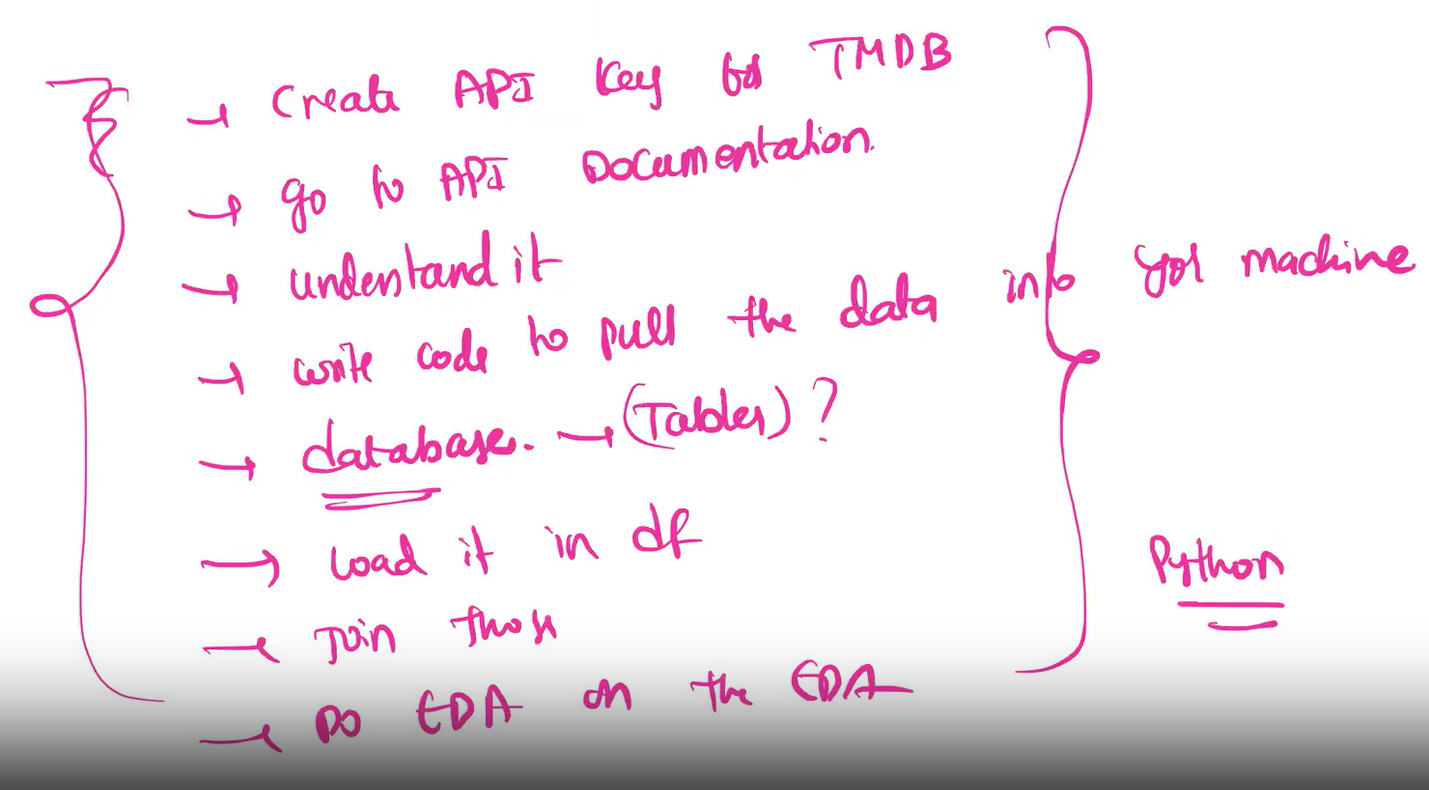

#### Task -1: Creating API Key
1. Create an account in TMDB website
2. In seeting -> API -> There will be an option to create an API Key. Fill all the details. Your API key will be created.

### Task - 2: Trying the API and converting them into Pandas DF
Now you have created an API key and saved it in .env file. Now try to load the API key and try to hit the API.


In [ ]:
import requests
import os
from dotenv import load_dotenv

url="https://api.themoviedb.org/3/authentication"
load_dotenv()
apiKey = os.getenv("Tmdb_Api_Key")
params = {"api_key":apiKey}
resp = requests.get(url,params=params)
print(f"Response code: {resp.status_code}")
print(f"Response: {resp.text}")


In [ ]:
# Genre List API
import json
url="https://api.themoviedb.org/3/genre/movie/list"

resp = requests.get(url,params=params)
print(f"Response code: {resp.status_code}")
print(f"Response in text format: {resp.text}")
genreJSON=resp.json()
print(f"Datatype of genreJSON: {type(genreJSON)}")
#Saving the json response in a json file.
#Dumping the data into json file
with open ("genreJSON.json","w") as contxtMgr:
    json.dump(genreJSON,contxtMgr)

#Fetching the data from json file and printing
with open ("genreJSON.json","r") as contxtMgr:
    print(f"Response in json format from file: {json.load(contxtMgr)}")


In [ ]:

import pandas as pd

#Since our json is a nested json, we are fetching the json file form file as dictionary, then converting it into a dataframe.
with open("D:\\Veena\\Certificate Program in Artificial Intelligence and Machine Learning\\Certificate-Program-in-AIML-IIT-Patna\\MODULE 1 - FOUNDATIONS OF DATA\\Module 1 - WorkshopProject\\genreJSON.json","r") as cursor:
    data = json.load(cursor)
    print(f"Data type of loaded json data: {type(data)}")
genreData = data['genres']
print(type(genreData))
genreDF = pd.DataFrame(genreData)
genreDF.head()

In [ ]:
# Discover Movie API
url="https://api.themoviedb.org/3/discover/movie"
params={"api_key":apiKey,"page":1}
resp=requests.get(url,params=params)
respJSON = resp.json()
#print(f"Response in json: {respJSON}")

movieDiscoverDF = pd.DataFrame(respJSON["results"])
movieDiscoverDF.head()


In [ ]:
# Fetch movie details API from id
def fetchMovieDetails(movieId):
    url = f"https://api.themoviedb.org/3/movie/{movieId}"
    params={"api_key":apiKey}
    resp = requests.get(url,params=params)
    print(f"Response in json: {resp.json()}")


fetchMovieDetails(83533)

### Task -3 : Create sql DB and tables to store the data fetched from API

In [ ]:
# ── Create SQLite database and all 5 tables ──────────────────────────
import sqlite3
DB="TMDBDataBase"
conn   = sqlite3.connect(DB)
cursor = conn.cursor()

cursor.executescript("""
    PRAGMA journal_mode=WAL;

    CREATE TABLE IF NOT EXISTS movies (
        movie_id          INTEGER PRIMARY KEY,
        title             TEXT    NOT NULL,
        original_title    TEXT,
        release_date      TEXT,
        release_year      INTEGER,
        release_month     INTEGER,
        runtime           INTEGER,
        budget            REAL,
        revenue           REAL,
        vote_average      REAL,
        vote_count        INTEGER,
        popularity        REAL,
        original_language TEXT,
        overview          TEXT,
        tagline           TEXT,
        is_franchise      INTEGER DEFAULT 0,
        collection_name   TEXT,
        fetched_at        TEXT
    );

    CREATE TABLE IF NOT EXISTS genres (
        genre_id   INTEGER PRIMARY KEY,
        genre_name TEXT NOT NULL
    );

    CREATE TABLE IF NOT EXISTS movie_genres (
        movie_id   INTEGER,
        genre_id   INTEGER,
        genre_name TEXT,
        PRIMARY KEY (movie_id, genre_id),
        FOREIGN KEY (movie_id) REFERENCES movies(movie_id),
        FOREIGN KEY (genre_id) REFERENCES genres(genre_id)
    );

    CREATE TABLE IF NOT EXISTS cast (
        id           INTEGER PRIMARY KEY AUTOINCREMENT,
        movie_id     INTEGER,
        actor_name   TEXT,
        character    TEXT,
        billing_order INTEGER,
        person_id    INTEGER,
        FOREIGN KEY (movie_id) REFERENCES movies(movie_id)
    );

    CREATE TABLE IF NOT EXISTS directors (
        id           INTEGER PRIMARY KEY AUTOINCREMENT,
        movie_id     INTEGER UNIQUE,
        director_name TEXT,
        person_id    INTEGER,
        FOREIGN KEY (movie_id) REFERENCES movies(movie_id)
    );
""")

conn.commit()
print("Database created:", DB)
print("Tables created:")
query="SELECT name FROM sqlite_master WHERE type='table'"
cursor.execute(query)
tables = cursor.fetchall()
for t in tables:
    print(f"table name:  {t[0]}")


### Task-4: Data Insertion into the Genre SQL table created.

In [ ]:
# One way of inserting data into the sql table. We are using normal list(json data from response instead of the dataframe itself)
cursor.execute("DELETE FROM genres")
cursor.executemany(
    "INSERT OR IGNORE INTO genres (genre_id, genre_name) VALUES (?, ?)",
    [(g["id"], g["name"]) for g in genreData]
)

query="select * from genres"
cursor.execute(query)
cursor.fetchone()


### Task 5: Fetching the discover movies data based on particular params and pushing the data into tables. 

In [ ]:
BASE="https://api.themoviedb.org/3"

In [ ]:
import time

DISCOVER_CONFIGS = [
    ("vote_count.desc",   50, "most voted"),
    ("revenue.desc",      25, "highest revenue"),
    ("vote_average.desc", 25, "highest rated"),
    ("popularity.desc",   20, "most popular recent"),
]

all_discovered = {}

for sort_by, pages, label in DISCOVER_CONFIGS:
    print(f"Discovering '{label}' ({pages} pages)...", end=" ", flush=True)
    for page in range(1, pages + 1):
        try:
            r = requests.get(
                f"{BASE}/discover/movie",
                params={"api_key": apiKey, "sort_by": sort_by, "vote_count.gte": 200, "page": page},
                timeout=15,
            )
            r.raise_for_status()
            for movie in r.json().get("results", []):
                all_discovered[movie["id"]] = movie
            time.sleep(0.125)
        except Exception as e:
            print(f"\n  Error page {page}: {e}")
            time.sleep(1)
    print(f"total unique so far: {len(all_discovered)}")

with open("discovered_ids.json", "w") as f:
    json.dump(list(all_discovered.keys()), f)
print(f"\nPass 1 done: {len(all_discovered)} unique movies discovered.")

In [ ]:
#This method is used to check if the data for the current movie has been inserted into table or not. For preventing duplicate insert. Here is not None will return as True/False. True is i is the o/p of the query(1 is not None), False if None is the o/p of the query(None is not None)
def already_fetched(conn, movie_id):
    return conn.execute("SELECT 1 FROM movies WHERE movie_id=?", (movie_id,)).fetchone() is not None


In [ ]:
def parse_year_month(date_str):
    if not date_str:
        return None, None
    try:
        dt = datetime.strptime(date_str, "%Y-%m-%d")
        return dt.year, dt.month
    except (ValueError, TypeError):
        return None, None
    

def extract_director(crew_list):
    for member in crew_list:
        if member.get("job") == "Director":
            return member.get("name"), member.get("id")
    return None, None    

In [ ]:
import datetime

def insert_movie(conn, data, credits):
    cur = conn.cursor()
    mid = data["id"]
    year, month = parse_year_month(data.get("release_date"))
    collection = data.get("belongs_to_collection")
    is_franchise = 1 if collection else 0
    collection_name = collection["name"] if collection else None

    cur.execute("""
        INSERT OR REPLACE INTO movies (
            movie_id, title, original_title, release_date,
            release_year, release_month, runtime, budget, revenue,
            vote_average, vote_count, popularity, original_language,
            overview, tagline, is_franchise, collection_name, fetched_at
        ) VALUES (?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?)
    """, (
        mid, data.get("title"), data.get("original_title"), data.get("release_date"),
        year, month, data.get("runtime"), data.get("budget"), data.get("revenue"),
        data.get("vote_average"), data.get("vote_count"), data.get("popularity"),
        data.get("original_language"), data.get("overview"), data.get("tagline"),
        is_franchise, collection_name, datetime.now().isoformat(),
    ))

    for genre in data.get("genres", []):
        cur.execute(
            "INSERT OR IGNORE INTO movie_genres (movie_id, genre_id, genre_name) VALUES (?,?,?)",
            (mid, genre["id"], genre["name"]),
        )

    for actor in credits.get("cast", [])[:5]:
        cur.execute(
            "INSERT OR IGNORE INTO cast (movie_id, actor_name, character, billing_order, person_id) VALUES (?,?,?,?,?)",
            (mid, actor.get("name"), actor.get("character"), actor.get("order"), actor.get("id")),
        )

    director_name, director_id = extract_director(credits.get("crew", []))
    if director_name:
        cur.execute(
            "INSERT OR REPLACE INTO directors (movie_id, director_name, person_id) VALUES (?,?,?)",
            (mid, director_name, director_id),
        )


In [ ]:
movie_ids = list(all_discovered.keys())
total     = len(movie_ids)
success = skipped = errors = 0

print(f"\nPass 2: Fetching details for {total} movies (~{total * 0.125 / 60:.0f} min)...")

for i, movie_id in enumerate(movie_ids):
    if already_fetched(conn, movie_id):
        skipped += 1
        continue

    try:
        r = requests.get(
            f"{BASE}/movie/{movie_id}",
            params={"api_key": apiKey, "append_to_response": "credits"},
            timeout=15,
        )
        if r.status_code == 404:
            errors += 1
            continue

        r.raise_for_status()
        data = r.json()
        credits = data.pop("credits", {"cast": [], "crew": []})

        insert_movie(conn, data, credits)
        conn.commit()
        success += 1

        if success % 100 == 0:
            pct = (i + 1) / total * 100
            print(f"  [{pct:>5.1f}%]  {success} fetched  {skipped} skipped  {errors} errors")

        time.sleep(0.125)

    except requests.exceptions.Timeout:
        print(f"  Timeout on {movie_id}")
        errors += 1
        time.sleep(1)
    except requests.exceptions.HTTPError as e:
        if "429" in str(e):
            print("  Rate limited — sleeping 10s")
            time.sleep(10)
        else:
            errors += 1
    except Exception:
        errors += 1
        time.sleep(0.5)

print(f"\nPass 2 done!  Fetched: {success:,}  Skipped: {skipped:,}  Errors: {errors:,}")

# ── Verify ────────────────────────────────────────────────────────────
print(f"\n{'Table':<15} {'Rows':>8}")
print("-" * 25)
for table in ["movies", "genres", "movie_genres", "cast", "directors"]:
    count = conn.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
    print(f"  {table:<15} {count:>7,}")

conn.close()
print(f"\nDone. Database saved at: {DB}")
